In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [20]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    
    
llm = ChatOpenAI()

In [21]:
def chat_node(state: ChatState):
    #take user query from state
    messages = state['messages']
    #send to llm
    response = llm.invoke(messages)
    
    #response store state
    return {'messages': [response]}

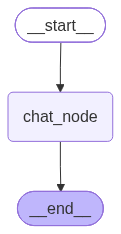

In [22]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

chatbot

In [25]:
initial_state = {
    'messages':[HumanMessage(content = 'What is the capital of India')]
}
thread_id = '1'
config = {'configurable': {'thread_id': thread_id}}
chatbot.invoke(initial_state,config=config)

{'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='f703af79-c3eb-49e9-9f90-21dc20ec7535'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EEBSaw7UUOFEOHHYBgxP1lEUCSIl8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01471-18fa-7673-a496-6f8fc8b4c258-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'c

In [27]:
thread_id = '1'

while True:
    user_message = input('Type here: ')
    
    print('User: ',user_message)
    
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({
        'messages': [HumanMessage(content = user_message)]
    },config=config)
    
    print('AI: ', response['messages'][-1].content)
    
chatbot.get_state(config=config)

User:  hi
AI:  Hello! How can I assist you today?
User:  vfe
AI:  I'm sorry, I didn't quite understand that. Can you please provide more information or let me know how I can assist you?
User:  what is this
AI:  I am a language model AI assistant designed to help answer questions and engage in conversation. How can I assist you today?
User:  where is india
AI:  India is a country located in South Asia, bordered by Pakistan to the northwest, China and Nepal to the north, Bhutan to the northeast, and Bangladesh and Myanmar to the east. It is bounded by the Indian Ocean to the south.
User:  where is south asia
AI:  South Asia is a region in Asia that includes countries like India, Pakistan, Bangladesh, Sri Lanka, Nepal, Bhutan, and the Maldives. It is located south of the Himalayas and includes the Indian subcontinent.
User:  where is that
AI:  The Indian subcontinent is a region in South Asia that includes the countries of India, Nepal, Bhutan, and part of Bangladesh. It is located in the

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='f703af79-c3eb-49e9-9f90-21dc20ec7535'), AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EEBSaw7UUOFEOHHYBgxP1lEUCSIl8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01471-18fa-7673-a496-6f8fc8b4c258-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_detail

In [28]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='f703af79-c3eb-49e9-9f90-21dc20ec7535'), AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EEBSaw7UUOFEOHHYBgxP1lEUCSIl8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01471-18fa-7673-a496-6f8fc8b4c258-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_detail